In [28]:
# Re-run after state reset

# Parse the provided log format and plot each metric over time (Train vs Valid)
# - Uses matplotlib (no seaborn), each chart in its own figure
# - Saves figures to /mnt/data and shows them inline
# - Displays a parsed DataFrame for inspection
import re
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [39]:
pat = re.compile(
    r"""
    ^\[(?P<epoch>\d+)\/(?P<epoch_max>\d+)\]      # [cur/max]
    \[(?P<iter>\d+)\]                             # [iter]
    \[(?P<phase>Train|Valid)\]\s+                # [phase]
    recon:\s+(?P<recon>[0-9.eE+\-]+)\s+
    exp-z:\s+(?P<exp_z>[0-9.eE+\-]+)\s+
    exp-v:\s+(?P<exp_v>[0-9.eE+\-]+)\s+
    shape:\s+(?P<shape>[0-9.eE+\-]+)\s+
    total:\s+(?P<total>[0-9.eE+\-]+)\s*
    $
    """,
    re.VERBOSE
)

def parse_log_file(path: str | Path, as_delta: bool = False) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = pat.match(line)
            if not m:
                continue
            g = m.groupdict()
            rows.append({
                "epoch":       int(g["epoch"]),
                "epoch_max":   int(g["epoch_max"]),
                "iter":        int(g["iter"]),
                "phase":       g["phase"],
                "recon":       float(g["recon"]),
                "exp_z":       float(g["exp_z"]),
                "exp_v":       float(g["exp_v"]),
                "shape":       float(g["shape"]),
                "total":       float(g["total"]),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    
    phase_key = {"Train": 0, "Valid": 1}
    df["phase_key"] = df["phase"].map(phase_key)
    df = df.sort_values(["epoch", "iter", "phase_key"]).reset_index(drop=True)
    
    df["x"] = np.nan
    for phase in df["phase"].unique():
        dph = df[df["phase"] == phase]
        for ep in dph["epoch"].unique():
            mask = (df["phase"] == phase) & (df["epoch"] == ep)
            iters = df.loc[mask, "iter"]
            denom = max(int(iters.max()), 1)
            df.loc[mask, "x"] = ep + iters.to_numpy() / float(denom)

    # per phase running index
    df["idx_phase"] = 0
    for phase in df["phase"].unique():
        mask = df["phase"] == phase
        df.loc[mask, "idx_phase"] = np.arange(mask.sum())
    
    if as_delta:
        keys = ["recon", "shape", "exp_z", "exp_v", "total"]
        df[keys] = (
            df.groupby(["phase", "epoch"], sort=False)[keys]
              .diff()
              .fillna(0.0)
        )

    df = df.drop(columns=["phase_key"])
    return df
    
# ------------------------------
# 3) Plot helpers
# ------------------------------

def plot_metric(df: pd.DataFrame, metric: str, x_key: str = "x",
                yscale: str = "symlog", linthresh: float = 1e-12,
                save_dir: str | Path = "./_tmp/log_vis",
                mode: int = 0,
               ):
    """
    yscale:
      - 'linear': ordinary linear
      - 'log': log10 (only positive values)
      - 'symlog': safe around zero (recommended when metric can be zero)
    linthresh: symlog linear range half-width around 0.
    """
    if df.empty:
        print(f"No data to plot for metric '{metric}'"); 
        return None

    fig = plt.figure(figsize=(7, 4.5))
    ax = fig.add_subplot(111)

    
    if mode == 0:
        phases = ["Train"]
    elif mode == 1:
        phases = ["Valid"]
    else:
        phases = ["Train", "Valid"]
        
    for phase in phases:
        d = df[df["phase"] == phase]
        if d.empty:
            continue
        ax.plot(d[x_key].to_numpy(), d[metric].to_numpy(), label=phase, linewidth=1.8)

    # Choose y-scale
    if yscale == "log":
        # guard: ensure positive
        ymin = df[metric].replace(0, np.nan).min(skipna=True)
        if not np.isfinite(ymin) or ymin <= 0:
            # fallback safely to symlog if non-positive present
            ax.set_yscale("symlog", linthresh=linthresh)
        else:
            ax.set_yscale("log")
    elif yscale == "symlog":
        ax.set_yscale("symlog", linthresh=linthresh)
    else:
        ax.set_yscale("linear")

    ax.set_title(f"{metric} over time ({yscale})")
    ax.set_xlabel(x_key)
    ax.set_ylabel(metric)
    ax.grid(True, which="both", alpha=0.4)
    ax.legend()

    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"logplot_{metric}_{yscale}.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    return str(out_path)

def plot_all_metrics_subfig(
        df: pd.DataFrame,
        metrics=["recon", "exp_z", "exp_v", "shape", "total"],
        x_key="x",
        yscale="symlog",          # 'linear' | 'log' | 'symlog'
        linthresh=1e-8,           # for symlog
        ncols=2,
        figsize=(12, 9),
        mode: int = 0,
        save_path: str | Path | None = "./_tmp",
    ):
    assert not df.empty, "Empty dataframe"

    n = len(metrics)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    if isinstance(axes, np.ndarray):
        axes = axes.ravel()
    else:
        axes = [axes]
    
    if mode == 0:
        phases = ["Train"]
    elif mode == 1:
        phases = ["Valid"]
    else:
        phases = ["Train", "Valid"]
        
    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Train/Valid
        for phase in phases:
            d = df[df["phase"] == phase]
            if d.empty:
                continue
            ax.plot(d[x_key].to_numpy(), d[metric].to_numpy(), label=phase, alpha=0.5, linewidth=1.6)
        
        if yscale == "log":
            ymin = df[metric].replace(0, np.nan).min(skipna=True)
            if not np.isfinite(ymin) or ymin <= 0:
                ax.set_yscale("symlog", linthresh=linthresh)
            else:
                ax.set_yscale("log")
        elif yscale == "symlog":
            ax.set_yscale("symlog", linthresh=linthresh)
        else:
            ax.set_yscale("linear")

        ax.set_title(metric)
        ax.set_xlabel(x_key)
        ax.grid(True, which="both", alpha=0.35)
        ax.legend(fontsize=9)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved -> {save_path}")
    return fig

Saved -> logplots_all_metrics.png


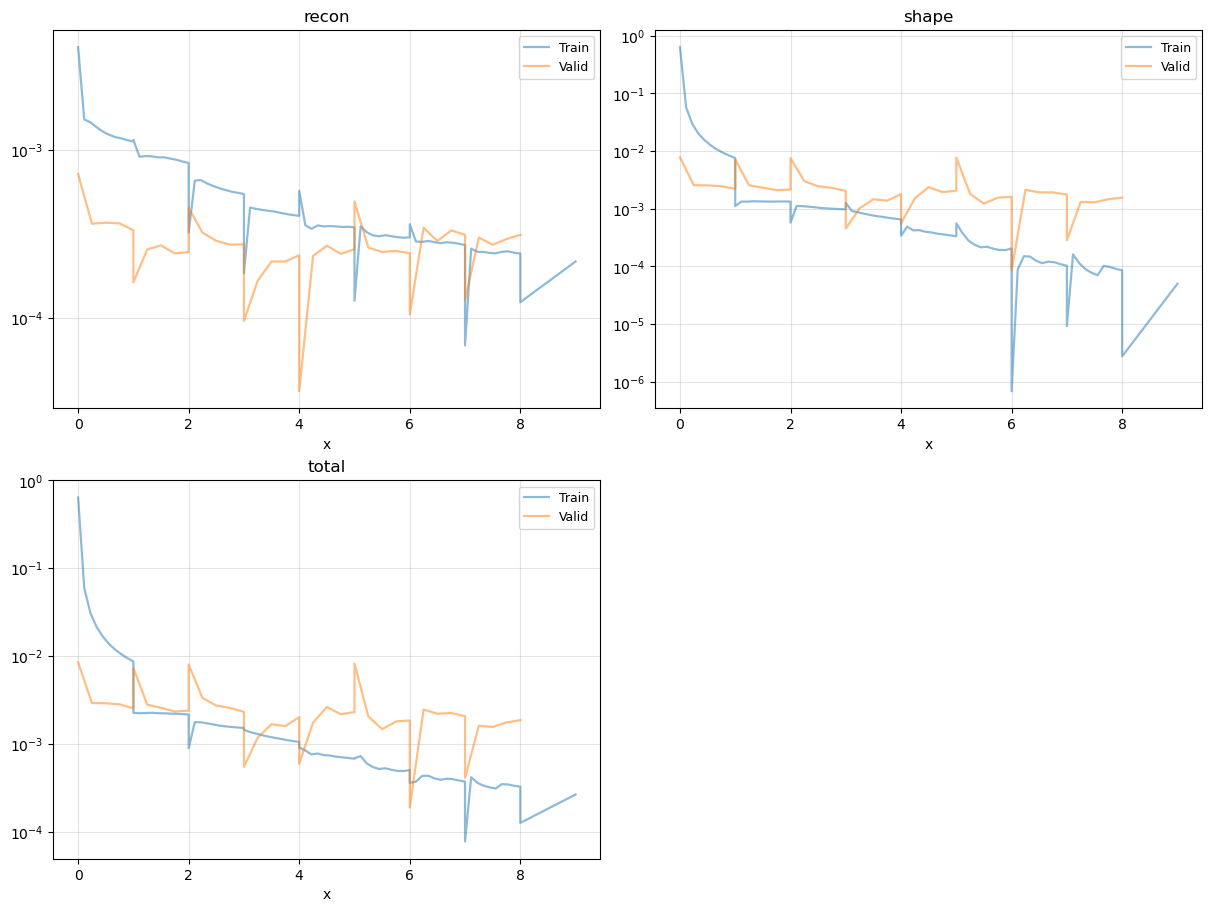

In [49]:
# log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-08-13-21-05-NGBC" # -> as_delta=True
log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-10-11-20-25-NGBC"
log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-11-15-26-03-NGBC"

df = parse_log_file(log_path+"/log.txt", as_delta=False)
# df = parse_log_file(log_path+"/log.txt", as_delta=True)

# # paths = {}
# # # for metric in ["recon", "exp_z", "exp_v", "shape", "total"]:
# # for metric in ["recon", "shape", "total"]:
# #     p = plot_metric(df, metric, x_key="x", save_dir="/_tmp/data")
# #     if p is not None:
# #         paths[metric] = p

# _ = plot_metric(df, "recon", x_key="x", mode=1)         # epoch+iter 정규화 축
# _ = plot_metric(df, "shape", x_key="x", mode=1)         # epoch+iter 정규화 축
# _ = plot_metric(df, "total", x_key="x", mode=1)
# # 또는
# #_ = plot_metric(df, "total", x_key="idx_phase")  # phase별 누적 인덱스 축

fig = plot_all_metrics_subfig(
    df, 
    # yscale="log",
    yscale="symlog",
    metrics=["recon", "shape", "total"],
    ncols=2, figsize=(12, 9), mode=-1,
    save_path="logplots_all_metrics.png"
)
plt.show()
